# 08 Driving Postprocess Contract v1

이 노트북은 07에서 확정한 lane decoder 출력값을 **실제 조향 명령**으로 바꾸는 contract를 정한다.

08은 이전의 단순 corridor-center 방식이 아니라, 12번 라벨의 의미에 맞춰 **local tangent + temporal recovery steering**으로 설계한다.

- 12번 라벨은 전체 도로 중앙선을 예쁘게 맞히는 것이 아니라, 차가 바로 앞에서 따라갈 수 있는 local lane direction을 학습시키기 위해 만들었다.
- 따라서 주행 후처리도 lane 후보의 위치만 보지 않고, 가까운 구간의 기울기와 최근 프레임의 회전 추세를 함께 본다.
- lost frame에서도 정지하지 않고, 마지막 steering/turn bias를 이용해 차선이 다시 보이는 방향으로 복구 주행한다.

## 이번 08에서 정할 것

07이 정한 것은 `raw model output -> decoded lane candidates`까지다.  
08이 정하는 것은 `decoded lane candidates -> steering command`다.

이번 설계의 핵심은 다음과 같다.

1. Lane 후보마다 아래쪽 가까운 구간에서 tangent를 계산한다.
2. 양쪽 lane이 안정적으로 보이면 corridor center와 평균 tangent를 함께 쓴다.
3. 한쪽 lane만 보이면 corridor 폭의 절반이 아니라, boundary에서 안전 거리만큼 떨어진 target trajectory를 만든다.
4. frame 간 lane/mode가 갑자기 튀면 그 frame을 바로 믿지 않고 짧게 trajectory를 hold한다.
5. lane이 사라져도 멈추지 않고, 최근 steer와 turn bias로 recovery steering을 유지한다.

즉 목표는 예쁜 중앙선 추정이 아니라 **맵 이탈 방지와 lane 재탐지 가능성 유지**다.

In [1]:
from pathlib import Path
import os
import sys
import json
import time
import math

import numpy as np
import pandas as pd
import cv2
import torch

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

from IPython.display import display, Image, Markdown

EXP_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild")
SHARED_LANE_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\lane")
RAW_ROOT = SHARED_LANE_ROOT / "raw"

DECODE_REVIEW_ROOT = EXP_ROOT / "review_outputs" / "07_decode_contract_v1"
DECODE_CONTRACT_PATH = DECODE_REVIEW_ROOT / "decode_contract_v1.json"

REVIEW_ROOT = EXP_ROOT / "review_outputs" / "08_driving_postprocess_contract_v1"
TABLE_DIR = REVIEW_ROOT / "tables"
OVERLAY_DIR = REVIEW_ROOT / "overlays"
VIDEO_DIR = REVIEW_ROOT / "videos"
for d in [REVIEW_ROOT, TABLE_DIR, OVERLAY_DIR, VIDEO_DIR]:
    d.mkdir(parents=True, exist_ok=True)

FIELD3_FRAME_LIMIT = None
WRITE_OVERLAY = True
WRITE_VIDEO = True
VIDEO_FPS = 12

print("EXP_ROOT:", EXP_ROOT)
print("REVIEW_ROOT:", REVIEW_ROOT)


EXP_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild
REVIEW_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08_driving_postprocess_contract_v1


In [2]:
def long_path(path):
    p = Path(path)
    s = str(p.resolve())
    if sys.platform.startswith("win") and not s.startswith("\\\\?\\"):
        return "\\\\?\\" + s
    return s


def exists_path(path):
    return os.path.exists(long_path(path))


def read_text(path, encoding="utf-8"):
    with open(long_path(path), "r", encoding=encoding) as f:
        return f.read()


def write_text(path, text, encoding="utf-8"):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(long_path(path), "w", encoding=encoding) as f:
        f.write(text)


def imread_bgr(path):
    data = np.fromfile(long_path(path), dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"cv2.imdecode failed: {path}")
    return img


def imwrite_bgr(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    ok, buf = cv2.imencode(path.suffix or ".jpg", image)
    if not ok:
        raise RuntimeError(f"cv2.imencode failed: {path}")
    buf.tofile(long_path(path))
    return path


def load_py_config_without_temp(config_path):
    from clrkd.utils.config import Config
    text = read_text(config_path)
    ns = {}
    exec(compile(text, str(config_path), "exec"), ns)
    cfg_dict = {k: v for k, v in ns.items() if not k.startswith("__")}
    return Config(cfg_dict, cfg_text=text, filename=str(config_path))

print("helpers ready")


helpers ready


In [3]:
assert DECODE_CONTRACT_PATH.exists(), f"missing 07 decode contract: {DECODE_CONTRACT_PATH}"
decode_contract = json.loads(read_text(DECODE_CONTRACT_PATH))
decoder_cfg = decode_contract["decoder_contract"]

CODE_DIR = Path(decode_contract.get("code_dir", "")) if decode_contract.get("code_dir") else Path(decode_contract["model_checkpoint"]).parents[1] / "code"
CONFIG_PATH = Path(decode_contract["config"])
BEST_CKPT = Path(decode_contract["model_checkpoint"])

required_paths = {
    "CODE_DIR": CODE_DIR,
    "CONFIG_PATH": CONFIG_PATH,
    "BEST_CKPT": BEST_CKPT,
    "FIELD3_RAW": RAW_ROOT / "field3",
}
for name, path in required_paths.items():
    print(f"{name:12s}", path, "exists=", path.exists())
    assert path.exists(), f"missing required path: {name} -> {path}"

print("decoder contract:", decoder_cfg)
assert decoder_cfg["name"] == "official_overlap_python"


CODE_DIR     ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\colab_outputs\MapLane_LocalFit_Field12_v1_full\20260509_102232_lr_1e-04_b_8\code exists= True
CONFIG_PATH  ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\colab_outputs\meta\MapLane_LocalFit_Field12_v1_ResNet18_full.py exists= True
BEST_CKPT    ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\colab_outputs\MapLane_LocalFit_Field12_v1_full\20260509_102232_lr_1e-04_b_8\ckpt\best.pth exists= True
FIELD3_RAW   ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\lane\raw\field3 exists= True
decoder contract: {'name': 'official_overlap_python', 'conf_threshold': 0.35, 'nms_thres': 70.0, 'nms_topk': 4, 'source': 'Python port of clrkd/ops/csrc/nms_kernel.cu devIoU + greedy keep order', 'status': 'selecte

## 모델과 07 decoder 로딩

08은 07 decoder contract를 그대로 사용한다.

- 입력: BGR `[0, 1]`, `raw_y >= cut_height`
- decoder: `official_overlap_python`
- confidence: 0.35
- NMS threshold: 70 px

여기서 모델과 decoder를 다시 로딩하는 이유는 08이 단독으로 Run All 되었을 때도 같은 lane candidates를 재생성할 수 있게 하기 위해서다.

In [4]:
sys.path.insert(0, str(CODE_DIR))

from clrkd.models.registry import build_net

cfg = load_py_config_without_temp(CONFIG_PATH)
print("cfg sample_y:", list(cfg.sample_y)[:3], "...", list(cfg.sample_y)[-3:])
print("cfg geometry:", cfg.ori_img_w, cfg.ori_img_h, cfg.cut_height, cfg.img_w, cfg.img_h)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = build_net(cfg).to(device)
ckpt = torch.load(long_path(BEST_CKPT), map_location=device)
state = ckpt["net"] if isinstance(ckpt, dict) and "net" in ckpt else ckpt
state = {k.replace("module.", "", 1): v for k, v in state.items()}
missing, unexpected = model.load_state_dict(state, strict=False)
print("missing:", len(missing), missing[:5])
print("unexpected:", len(unexpected), unexpected[:5])
assert len(missing) == 0 and len(unexpected) == 0
model.eval()
head = model.heads

print("model loaded")


cfg sample_y: [971, 951, 931] ... [491, 471, 451]
cfg geometry: 1296 972 445 800 320
device: cpu
missing: 0 []
unexpected: 0 []
model loaded


In [5]:
def preprocess_bgr_for_model(bgr, cfg):
    crop = bgr[cfg.cut_height:, :, :]
    resized = cv2.resize(crop, (cfg.img_w, cfg.img_h), interpolation=cv2.INTER_LINEAR)
    tensor = resized.astype(np.float32).transpose(2, 0, 1)[None, ...] / 255.0
    return torch.from_numpy(tensor)


def image_paths_under(root):
    exts = {".jpg", ".jpeg", ".png", ".bmp"}
    root = Path(root)
    if not root.exists():
        return []
    return sorted([p for p in root.rglob("*") if p.suffix.lower() in exts], key=lambda p: str(p))


field3_paths_all = image_paths_under(RAW_ROOT / "field3")
assert field3_paths_all, "no field3 raw images found"
probe_bgr = imread_bgr(field3_paths_all[0])
probe_tensor = preprocess_bgr_for_model(probe_bgr, cfg)
print("probe:", probe_bgr.shape, tuple(probe_tensor.shape), float(probe_tensor.min()), float(probe_tensor.max()))
assert probe_tensor.dtype == torch.float32
assert 0.0 <= float(probe_tensor.min()) <= 1.0
assert 0.0 <= float(probe_tensor.max()) <= 1.0

with torch.no_grad():
    probe_raw = model({"img": probe_tensor.to(device)})
print("raw output:", tuple(probe_raw.shape))
assert tuple(probe_raw.shape[-2:]) == (cfg.heads.num_priors, 2 + 4 + cfg.num_points)


probe: (972, 1296, 3) (1, 3, 320, 800) 0.15294118225574493 0.9019607901573181
raw output: (1, 192, 78)


In [6]:
def prepare_nms_predictions(predictions, head):
    nms_predictions = predictions.detach().clone()
    nms_predictions = torch.cat([nms_predictions[..., :4], nms_predictions[..., 5:]], dim=-1)
    nms_predictions[..., 4] = nms_predictions[..., 4] * head.n_strips
    nms_predictions[..., 5:] = nms_predictions[..., 5:] * (head.img_w - 1)
    return nms_predictions


def official_cuda_suppresses(a, b, threshold, n_offsets=72):
    n_strips = n_offsets - 1
    start_a = int(float(a[2]) * n_strips + 0.5)
    start_b = int(float(b[2]) * n_strips + 0.5)
    start = max(start_a, start_b)
    len_a = float(a[4])
    len_b = float(b[4])
    end_a = int(start_a + len_a - 1 + 0.5 - (1 if (len_a - 1) < 0 else 0))
    end_b = int(start_b + len_b - 1 + 0.5 - (1 if (len_b - 1) < 0 else 0))
    end = min(end_a, end_b, n_offsets - 1)
    if end < start:
        return False
    xa = a[5 + start: 5 + end + 1]
    xb = b[5 + start: 5 + end + 1]
    dist_sum = torch.sum(torch.abs(xa - xb))
    return bool(float(dist_sum.item()) < float(threshold) * (end - start + 1))


def nms_official_overlap_python(boxes, scores, overlap=70, top_k=4):
    order = torch.argsort(scores, descending=True)
    boxes = boxes.detach().cpu()
    kept = []
    for idx in order.detach().cpu():
        idx = int(idx.item())
        if len(kept) >= int(top_k):
            break
        duplicate = False
        for kept_idx in kept:
            if official_cuda_suppresses(boxes[idx], boxes[kept_idx], overlap, n_offsets=cfg.num_points):
                duplicate = True
                break
        if not duplicate:
            kept.append(idx)
    keep = torch.tensor(kept, dtype=torch.long)
    return keep, int(keep.numel())


def decode_one(raw_predictions):
    conf_threshold = float(decoder_cfg["conf_threshold"])
    nms_thres = float(decoder_cfg["nms_thres"])
    predictions = raw_predictions.detach().cpu().clone()
    scores = torch.softmax(predictions[:, :2], dim=1)[:, 1]
    keep_inds = scores >= conf_threshold
    predictions = predictions[keep_inds]
    scores = scores[keep_inds]
    if predictions.shape[0] == 0:
        return []

    nms_predictions = prepare_nms_predictions(predictions, head).cpu()
    keep, num_to_keep = nms_official_overlap_python(
        nms_predictions,
        scores.cpu(),
        overlap=nms_thres,
        top_k=cfg.max_lanes,
    )
    keep = keep[:num_to_keep]
    selected_scores = scores[keep].clone()
    predictions = predictions[keep]
    if predictions.shape[0] == 0:
        return []

    predictions[:, 1] = selected_scores
    predictions[:, 5] = torch.round(predictions[:, 5] * head.n_strips)
    return head.predictions_to_pred(predictions)


def lane_obj_to_json(lane_obj):
    pts = lane_obj.to_array(cfg)
    pts = np.asarray(pts, dtype=np.float32) if pts is not None else np.empty((0, 2), dtype=np.float32)
    meta = getattr(lane_obj, "metadata", {}) or {}
    conf = float(meta.get("conf", np.nan))
    return {"points": pts.tolist(), "conf": conf}

lanes_probe = decode_one(probe_raw.detach().cpu()[0])
print("probe decoded lanes:", len(lanes_probe), [float(l.metadata.get("conf", -1)) for l in lanes_probe])


probe decoded lanes: 2 [0.8885690569877625, 0.8183960914611816]


## Field3 sequence decode cache

08은 field3 sequence를 시간순으로 본다.  
첫 실행은 모델 forward와 decode를 수행하고, 이후에는 manifest가 같으면 cache를 재사용한다.

주의: 이 노트북은 steering 후처리를 실험하는 것이 목적이므로, 같은 decoded lanes 위에서 정책만 바꾼다.

In [7]:
def even_sample(items, max_count):
    items = list(items)
    if max_count is None or len(items) <= max_count:
        return items
    idx = np.linspace(0, len(items) - 1, max_count).round().astype(int)
    out, seen = [], set()
    for i in idx:
        i = int(i)
        if i not in seen:
            out.append(items[i])
            seen.add(i)
    return out


field3_paths = even_sample(field3_paths_all, FIELD3_FRAME_LIMIT)
field3_records = [
    {
        "set": "field3",
        "id": p.stem,
        "image_path": p,
        "rel": str(p.relative_to(RAW_ROOT / "field3")),
    }
    for p in field3_paths
]

print("field3 frames selected:", len(field3_records), "of", len(field3_paths_all))
print("first:", field3_records[0]["rel"])
print("last :", field3_records[-1]["rel"])


field3 frames selected: 1730 of 1730
first: field_drive\000000_mixed_drive_auto_20260501_191234_792.jpg
last : field_drive\001729_mixed_drive_auto_20260501_192018_574.jpg


In [8]:
RAW_CACHE_PATH = REVIEW_ROOT / "tangent_raw_outputs_field3.pt"
MANIFEST_PATH = REVIEW_ROOT / "tangent_raw_outputs_field3_manifest.csv"
DECODED_JSONL_PATH = REVIEW_ROOT / "tangent_decoded_lanes_field3.jsonl"


def record_key(rec):
    return f"{rec['set']}::{rec['id']}"


def manifest_from_records(records):
    rows = []
    for rec in records:
        p = Path(rec["image_path"])
        stat = p.stat()
        rows.append({
            "key": record_key(rec),
            "set": rec["set"],
            "id": rec["id"],
            "image_path": str(p),
            "rel": rec["rel"],
            "size": int(stat.st_size),
            "mtime_ns": int(stat.st_mtime_ns),
        })
    return pd.DataFrame(rows)


def manifest_matches(path, records):
    if not Path(path).exists():
        return False
    old = pd.read_csv(path)
    new = manifest_from_records(records)
    cols = ["key", "image_path", "size", "mtime_ns"]
    if len(old) != len(new):
        return False
    return old[cols].astype(str).reset_index(drop=True).equals(new[cols].astype(str).reset_index(drop=True))


def build_or_load_raw_cache(records):
    if RAW_CACHE_PATH.exists() and manifest_matches(MANIFEST_PATH, records):
        cache = torch.load(long_path(RAW_CACHE_PATH), map_location="cpu")
        if set(cache.keys()) == {record_key(r) for r in records}:
            print("loaded raw cache:", RAW_CACHE_PATH)
            return cache
        print("raw cache key mismatch; rebuilding")

    raw_cache = {}
    start = time.time()
    for rec in tqdm(records, desc="forward field3 raw outputs"):
        bgr = imread_bgr(rec["image_path"])
        tensor = preprocess_bgr_for_model(bgr, cfg).to(device)
        with torch.no_grad():
            raw = model({"img": tensor}).detach().cpu()[0]
        raw_cache[record_key(rec)] = raw
    torch.save(raw_cache, long_path(RAW_CACHE_PATH))
    manifest_from_records(records).to_csv(MANIFEST_PATH, index=False, encoding="utf-8-sig")
    print("saved raw cache:", RAW_CACHE_PATH)
    print("elapsed_min:", round((time.time() - start) / 60.0, 2))
    return raw_cache


raw_cache = build_or_load_raw_cache(field3_records)
print("raw cache frames:", len(raw_cache))


loaded raw cache: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08_driving_postprocess_contract_v1\tangent_raw_outputs_field3.pt
raw cache frames: 1730


In [9]:
def build_or_load_decoded_lanes(records, raw_cache):
    expected_keys = [record_key(r) for r in records]
    if DECODED_JSONL_PATH.exists():
        rows = [json.loads(line) for line in read_text(DECODED_JSONL_PATH).splitlines() if line.strip()]
        if [row["key"] for row in rows] == expected_keys:
            decoded = {row["key"]: row["lanes"] for row in rows}
            print("loaded decoded lanes:", DECODED_JSONL_PATH)
            return decoded
        print("decoded cache manifest mismatch; rebuilding")

    decoded = {}
    out_lines = []
    for rec in tqdm(records, desc="decode field3 lanes"):
        key = record_key(rec)
        lane_objs = decode_one(raw_cache[key])
        lanes = [lane_obj_to_json(l) for l in lane_objs]
        decoded[key] = lanes
        out_lines.append(json.dumps({
            "key": key,
            "id": rec["id"],
            "rel": rec["rel"],
            "lanes": lanes,
        }, ensure_ascii=False))
    write_text(DECODED_JSONL_PATH, "\n".join(out_lines) + "\n")
    print("saved decoded lanes:", DECODED_JSONL_PATH)
    return decoded


decoded_by_key = build_or_load_decoded_lanes(field3_records, raw_cache)
lane_counts = [len(decoded_by_key[record_key(r)]) for r in field3_records]
print("mean decoded lanes:", float(np.mean(lane_counts)), "pct no lane:", float(np.mean(np.asarray(lane_counts) == 0)))


loaded decoded lanes: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08_driving_postprocess_contract_v1\tangent_decoded_lanes_field3.jsonl
mean decoded lanes: 1.676878612716763 pct no lane: 0.061849710982658956


## Inside-memory steering 재설계

이제 08의 주행 후처리를 다시 단순화한다.

이전 v2는 `lane quality` 점수와 화면 중앙 기준 `left/right` 판정을 같이 썼다.  
그 방식은 수치상 안정적이었지만, 한쪽 lane만 보일 때 다음 문제가 있었다.

1. 화면 중앙 기준으로 `left/right`를 바로 확정하면 곡선에서 side를 오판할 수 있다.
2. side를 오판하면 `safe_offset_px` 방향이 반대로 적용된다.
3. `unstable_hold`가 이전 회전 기억을 너무 오래 끌고 갈 수 있다.

이번 버전의 원칙은 더 단순하다.

```text
07 decoder lane 후보
→ 조향에 쓸 수 있는 최소 조건만 확인
→ 양쪽 pair가 자연스러우면 pair 사용
→ 한쪽 lane이면 left/right 두 가설을 모두 만든다
→ 이전 frame memory와 더 자연스럽게 이어지는 가설 선택
→ tangent heading + 안쪽 offset으로 steer 계산
→ lane lost 때는 정지하지 않고 최근 회전 기억으로 recovery
```

중요한 변화:

- 복잡한 lane quality 점수 제거
- single lane을 바로 left/right로 확정하지 않음
- `0.3`, `0.5`, `0.7`처럼 읽기 쉬운 smoothing/blend 값 사용
- jump guard는 영구 hold가 아니라, 연속으로 들어오면 새 측정값을 점점 더 받아들임


In [10]:
RAW_W = int(cfg.ori_img_w)
RAW_H = int(cfg.ori_img_h)
CUT_HEIGHT = int(cfg.cut_height)
IMAGE_CENTER_X = RAW_W / 2.0


def y_at_ratio(ratio):
    y = CUT_HEIGHT + (RAW_H - 1 - CUT_HEIGHT) * float(ratio)
    return float(np.clip(y, CUT_HEIGHT, RAW_H - 1))


def normalize_lane_points(points):
    pts = np.asarray(points, dtype=np.float32)
    if pts.ndim != 2 or pts.shape[1] != 2:
        return np.empty((0, 2), dtype=np.float32)
    pts = pts[np.isfinite(pts).all(axis=1)]
    if len(pts) < 2:
        return np.empty((0, 2), dtype=np.float32)
    order = np.argsort(pts[:, 1])
    pts = pts[order]

    # Same y can appear more than once after decode. Average it so interpolation is stable.
    rows = []
    for y in np.unique(pts[:, 1]):
        mask = pts[:, 1] == y
        rows.append([float(pts[mask, 0].mean()), float(y)])
    return np.asarray(rows, dtype=np.float32)


def interp_or_nearest_x(pts, y, max_y_distance):
    if len(pts) < 2:
        return float("nan"), float("inf")
    ys, xs = pts[:, 1], pts[:, 0]
    if float(ys.min()) <= y <= float(ys.max()):
        return float(np.interp(y, ys, xs)), 0.0
    idx = int(np.argmin(np.abs(ys - y)))
    dist = float(abs(ys[idx] - y))
    if dist <= float(max_y_distance):
        return float(xs[idx]), dist
    return float("nan"), dist


def lane_feature(lane, pp, lane_index=0):
    # Return a minimal steering feature, not a learned/handmade quality score.
    pts = normalize_lane_points(lane["points"])
    if len(pts) < int(pp["min_points"]):
        return None

    y_span = float(pts[:, 1].max() - pts[:, 1].min())
    if y_span < float(pp["min_y_span"]):
        return None

    y_top = y_at_ratio(pp["top_ratio"])
    y_primary = y_at_ratio(pp["primary_ratio"])
    y_bottom = y_at_ratio(pp["bottom_ratio"])
    x_top, dist_top = interp_or_nearest_x(pts, y_top, pp["max_y_distance"])
    x_primary, dist_primary = interp_or_nearest_x(pts, y_primary, pp["max_y_distance"])
    x_bottom, dist_bottom = interp_or_nearest_x(pts, y_bottom, pp["max_y_distance"])

    if not np.isfinite(x_primary):
        return None

    if np.isfinite(x_top) and np.isfinite(x_bottom):
        heading = float((x_top - x_bottom) / max(y_bottom - y_top, 1.0))
    else:
        heading = 0.0

    conf = float(lane.get("conf", np.nan))
    return {
        "lane_index": int(lane_index),
        "points": pts,
        "conf": conf,
        "x_top": float(x_top),
        "x_primary": float(x_primary),
        "x_bottom": float(x_bottom),
        "heading": float(np.clip(heading, -1.5, 1.5)),
        "y_span": y_span,
        "num_points": int(len(pts)),
        "dist_top": float(dist_top),
        "dist_primary": float(dist_primary),
        "dist_bottom": float(dist_bottom),
    }


def extract_features(lanes, pp):
    features = []
    for i, lane in enumerate(lanes):
        feat = lane_feature(lane, pp, lane_index=i)
        if feat is not None:
            features.append(feat)
    return features


print("inside-memory feature helpers ready")


inside-memory feature helpers ready


## 조절할 정책 값

여기서 조절하는 값들은 전부 사람이 읽고 바꾸기 쉽게 둥근 값으로 둔다.

핵심 값:

- `top_ratio`, `primary_ratio`, `bottom_ratio`: 아래쪽 어느 y 위치에서 tangent를 볼지
- `safe_offset_px`: 한쪽 boundary만 보일 때 그 안쪽으로 떨어질 거리
- `k_pos`: target 위치가 화면 중앙에서 벗어난 정도의 비중
- `k_heading`: target ray의 기울기 비중
- `center_alpha`, `heading_alpha`, `steer_alpha`: 새 값을 얼마나 반영할지
- `jump_center_px`, `jump_heading`: 새 측정값이 튄 것으로 볼 기준
- `jump_blend_*`: 튄 값도 연속으로 들어오면 점점 더 믿는 정도
- `max_steer_norm`: Pi에 넘기기 전 normalized steering cap

이 값들은 아직 최종 모터값이 아니다.  
Pi에서는 `steer_norm`을 다시 PWM/servo 값으로 변환해야 한다.


In [11]:
DRIVE_POLICIES = {
    "inside_soft": {
        "top_ratio": 0.8,
        "primary_ratio": 0.9,
        "bottom_ratio": 1.0,
        "safe_offset_px": 250.0,
        "min_points": 4,
        "min_y_span": 60,
        "max_y_distance": 150,
        "gap_min_px": 300,
        "gap_max_px": 1300,
        "single_side_deadband_px": 100,
        "side_prior_penalty_px": 300,
        "heading_cost_px": 200,
        "steer_cost_px": 200,
        "k_pos": 0.7,
        "k_heading": 0.5,
        "center_alpha": 0.5,
        "heading_alpha": 0.5,
        "steer_alpha": 0.5,
        "turn_bias_alpha": 0.3,
        "jump_center_px": 300,
        "jump_heading": 0.8,
        "jump_blend_start": 0.3,
        "jump_blend_step": 0.2,
        "jump_blend_max": 0.7,
        "lost_short_frames": 5,
        "lost_heading_decay": 0.9,
        "recovery_decay": 0.9,
        "recovery_gain": 0.1,
        "recovery_ramp": 0.03,
        "steer_gain": 0.9,
        "max_steer_norm": 0.7,
    },
    "inside_balanced": {
        "top_ratio": 0.8,
        "primary_ratio": 0.9,
        "bottom_ratio": 1.0,
        "safe_offset_px": 300.0,
        "min_points": 4,
        "min_y_span": 60,
        "max_y_distance": 150,
        "gap_min_px": 300,
        "gap_max_px": 1300,
        "single_side_deadband_px": 100,
        "side_prior_penalty_px": 300,
        "heading_cost_px": 200,
        "steer_cost_px": 200,
        "k_pos": 0.6,
        "k_heading": 0.7,
        "center_alpha": 0.5,
        "heading_alpha": 0.5,
        "steer_alpha": 0.5,
        "turn_bias_alpha": 0.3,
        "jump_center_px": 250,
        "jump_heading": 0.7,
        "jump_blend_start": 0.3,
        "jump_blend_step": 0.2,
        "jump_blend_max": 0.7,
        "lost_short_frames": 5,
        "lost_heading_decay": 0.9,
        "recovery_decay": 0.9,
        "recovery_gain": 0.2,
        "recovery_ramp": 0.04,
        "steer_gain": 0.9,
        "max_steer_norm": 0.8,
    },
    "inside_recovery": {
        "top_ratio": 0.8,
        "primary_ratio": 0.9,
        "bottom_ratio": 1.0,
        "safe_offset_px": 300.0,
        "min_points": 4,
        "min_y_span": 60,
        "max_y_distance": 150,
        "gap_min_px": 300,
        "gap_max_px": 1300,
        "single_side_deadband_px": 100,
        "side_prior_penalty_px": 300,
        "heading_cost_px": 200,
        "steer_cost_px": 200,
        "k_pos": 0.5,
        "k_heading": 0.8,
        "center_alpha": 0.5,
        "heading_alpha": 0.5,
        "steer_alpha": 0.5,
        "turn_bias_alpha": 0.3,
        "jump_center_px": 250,
        "jump_heading": 0.7,
        "jump_blend_start": 0.3,
        "jump_blend_step": 0.2,
        "jump_blend_max": 0.7,
        "lost_short_frames": 5,
        "lost_heading_decay": 0.9,
        "recovery_decay": 0.9,
        "recovery_gain": 0.2,
        "recovery_ramp": 0.05,
        "steer_gain": 0.9,
        "max_steer_norm": 0.8,
    },
}

display(pd.DataFrame([
    {"policy": name, **{k: v for k, v in pp.items() if isinstance(v, (int, float, str))}}
    for name, pp in DRIVE_POLICIES.items()
]))


,policy,top_ratio,primary_ratio,bottom_ratio,safe_offset_px,min_points,min_y_span,max_y_distance,gap_min_px,gap_max_px,...,jump_blend_start,jump_blend_step,jump_blend_max,lost_short_frames,lost_heading_decay,recovery_decay,recovery_gain,recovery_ramp,steer_gain,max_steer_norm
0,inside_soft,0.8,0.9,1.0,250.0,4,60,150,300,1300,...,0.3,0.2,0.7,5,0.9,0.9,0.1,0.03,0.9,0.7
1,inside_balanced,0.8,0.9,1.0,300.0,4,60,150,300,1300,...,0.3,0.2,0.7,5,0.9,0.9,0.2,0.04,0.9,0.8
2,inside_recovery,0.8,0.9,1.0,300.0,4,60,150,300,1300,...,0.3,0.2,0.7,5,0.9,0.9,0.2,0.05,0.9,0.8


## Steering core 구현

이 셀의 핵심은 `single lane dual hypothesis`다.

한쪽 lane만 보일 때 이전처럼 바로 left/right를 찍지 않는다.

```text
같은 lane에 대해 두 가설을 만든다.

가설 A: 이 lane은 left boundary다  → target = lane_x + safe_offset
가설 B: 이 lane은 right boundary다 → target = lane_x - safe_offset
```

그리고 둘 중에서 다음 조건에 더 자연스러운 것을 고른다.

- 이전 smoothed center와 너무 멀지 않은가
- 이전 smoothed heading과 너무 다르지 않은가
- 이전 steer와 갑자기 반대로 튀지 않는가
- memory가 없으면 화면 중앙 기준 prior를 약하게만 쓴다

즉 화면 중앙 기준은 아직 사용하지만, **초기 prior**일 뿐이다.  
프레임이 진행되면 memory 연속성이 더 중요해진다.


In [12]:
class DriveMemory:
    def __init__(self):
        self.last_measured_center_x = float("nan")
        self.smoothed_center_x = float("nan")
        self.smoothed_heading = 0.0
        self.turn_bias = 0.0
        self.last_steer = 0.0
        self.lost_frames = 0
        self.unstable_frames = 0
        self.last_mode = "boot"
        self.last_side = "unknown"
        self.last_left_x = float("nan")
        self.last_right_x = float("nan")
        self.last_pair_gap = float("nan")


def target_heading_from_points(x_top, x_bottom, pp):
    y_top = y_at_ratio(pp["top_ratio"])
    y_bottom = y_at_ratio(pp["bottom_ratio"])
    if np.isfinite(x_top) and np.isfinite(x_bottom):
        return float(np.clip((x_top - x_bottom) / max(y_bottom - y_top, 1.0), -1.5, 1.5))
    return 0.0


def raw_steer_for(center_x, heading, pp):
    pos_error = (float(center_x) - IMAGE_CENTER_X) / IMAGE_CENTER_X
    steer = float(pp["steer_gain"]) * (
        float(pp["k_pos"]) * pos_error
        + float(pp["k_heading"]) * float(heading)
    )
    return float(np.clip(steer, -float(pp["max_steer_norm"]), float(pp["max_steer_norm"])))


def pair_hypothesis(left, right, pp):
    x_top = np.nanmean([left["x_top"], right["x_top"]])
    x_primary = (left["x_primary"] + right["x_primary"]) / 2.0
    x_bottom = np.nanmean([left["x_bottom"], right["x_bottom"]])
    heading = target_heading_from_points(x_top, x_bottom, pp)
    gap = right["x_primary"] - left["x_primary"]
    return {
        "raw_mode": "both_stable",
        "reason": "valid_pair",
        "center_x": float(x_primary),
        "heading": float(heading),
        "left_x": float(left["x_primary"]),
        "right_x": float(right["x_primary"]),
        "pair_gap": float(gap),
        "selected_side": "pair",
        "source_lane_index": -1,
    }


def single_hypothesis(feat, side, pp):
    offset = float(pp["safe_offset_px"])
    sign = 1.0 if side == "left" else -1.0
    center_x = feat["x_primary"] + sign * offset
    x_top = feat["x_top"] + sign * offset if np.isfinite(feat["x_top"]) else float("nan")
    x_bottom = feat["x_bottom"] + sign * offset if np.isfinite(feat["x_bottom"]) else float("nan")
    heading = target_heading_from_points(x_top, x_bottom, pp)
    return {
        "raw_mode": f"single_{side}",
        "reason": f"single_{side}_hypothesis",
        "center_x": float(center_x),
        "heading": float(heading),
        "left_x": float(feat["x_primary"]) if side == "left" else float("nan"),
        "right_x": float(feat["x_primary"]) if side == "right" else float("nan"),
        "pair_gap": float("nan"),
        "selected_side": side,
        "source_lane_index": int(feat["lane_index"]),
    }


def side_prior_cost(feat, side, pp):
    deadband = float(pp["single_side_deadband_px"])
    penalty = float(pp["side_prior_penalty_px"])
    x = feat["x_primary"]
    if x < IMAGE_CENTER_X - deadband:
        likely = "left"
    elif x > IMAGE_CENTER_X + deadband:
        likely = "right"
    else:
        likely = "unknown"
    if likely == "unknown" or likely == side:
        return 0.0
    return penalty


def continuity_cost(hyp, memory, pp, feat=None):
    center_x = hyp["center_x"]
    heading = hyp["heading"]
    steer = raw_steer_for(center_x, heading, pp)

    if np.isfinite(memory.smoothed_center_x):
        center_cost = abs(center_x - memory.smoothed_center_x)
        heading_cost = abs(heading - memory.smoothed_heading) * float(pp["heading_cost_px"])
        steer_cost = abs(steer - memory.last_steer) * float(pp["steer_cost_px"])
        side_bonus = -80.0 if hyp["selected_side"] == memory.last_side else 0.0
        return center_cost + heading_cost + steer_cost + side_bonus

    # First frames: use a weak center prior only. This is not a hard side decision.
    center_cost = abs(center_x - IMAGE_CENTER_X) * 0.5
    prior_cost = side_prior_cost(feat, hyp["selected_side"], pp) if feat is not None else 0.0
    return center_cost + prior_cost


def choose_measurement(lanes, pp, memory):
    features = extract_features(lanes, pp)
    pair_candidates = []
    ordered = sorted(features, key=lambda f: f["x_primary"])
    for i, left in enumerate(ordered):
        for right in ordered[i + 1:]:
            gap = right["x_primary"] - left["x_primary"]
            if float(pp["gap_min_px"]) <= gap <= float(pp["gap_max_px"]):
                hyp = pair_hypothesis(left, right, pp)
                hyp["hypothesis_cost"] = continuity_cost(hyp, memory, pp)
                pair_candidates.append(hyp)

    if pair_candidates:
        best_pair = min(pair_candidates, key=lambda h: h["hypothesis_cost"])
        best_pair["feature_count"] = int(len(features))
        best_pair["candidate_count"] = int(len(pair_candidates))
        return best_pair

    single_candidates = []
    for feat in features:
        for side in ["left", "right"]:
            hyp = single_hypothesis(feat, side, pp)
            # Do not reject aggressively. Just penalize targets far outside the image.
            outside = max(0.0, -hyp["center_x"], hyp["center_x"] - (RAW_W - 1))
            hyp["hypothesis_cost"] = continuity_cost(hyp, memory, pp, feat=feat) + outside * 2.0
            single_candidates.append(hyp)

    if single_candidates:
        best = min(single_candidates, key=lambda h: h["hypothesis_cost"])
        best["feature_count"] = int(len(features))
        best["candidate_count"] = int(len(single_candidates))
        return best

    return {
        "raw_mode": "lost",
        "reason": "no_usable_lane_feature",
        "center_x": float("nan"),
        "heading": float("nan"),
        "left_x": float("nan"),
        "right_x": float("nan"),
        "pair_gap": float("nan"),
        "selected_side": "none",
        "source_lane_index": -1,
        "hypothesis_cost": float("nan"),
        "feature_count": int(len(features)),
        "candidate_count": 0,
    }


def apply_drive_policy(lanes, pp, memory):
    meas = choose_measurement(lanes, pp, memory)
    raw_mode = meas["raw_mode"]
    measured_center = meas["center_x"]
    measured_heading = meas["heading"]

    if np.isfinite(measured_center):
        center_jump = abs(measured_center - memory.last_measured_center_x) if np.isfinite(memory.last_measured_center_x) else 0.0
        heading_jump = abs(measured_heading - memory.smoothed_heading) if np.isfinite(measured_heading) else 0.0
        is_jump = center_jump > float(pp["jump_center_px"]) or heading_jump > float(pp["jump_heading"])
        memory.lost_frames = 0

        if is_jump and np.isfinite(memory.smoothed_center_x):
            memory.unstable_frames += 1
            blend = min(
                float(pp["jump_blend_max"]),
                float(pp["jump_blend_start"]) + float(pp["jump_blend_step"]) * (memory.unstable_frames - 1),
            )
            # A valid pair is stronger evidence than a single boundary, so reacquire faster.
            if raw_mode == "both_stable":
                blend = max(blend, 0.7)
            effective_center = (1.0 - blend) * memory.smoothed_center_x + blend * measured_center
            effective_heading = (1.0 - blend) * memory.smoothed_heading + blend * measured_heading
            effective_mode = "unstable_blend"
            reason = meas["reason"] + f"_blend_{blend:.1f}"
        else:
            memory.unstable_frames = 0
            effective_center = measured_center
            effective_heading = measured_heading
            effective_mode = raw_mode
            reason = meas["reason"]

        memory.last_measured_center_x = measured_center

        ca = float(pp["center_alpha"])
        ha = float(pp["heading_alpha"])
        if np.isfinite(memory.smoothed_center_x):
            memory.smoothed_center_x = ca * effective_center + (1.0 - ca) * memory.smoothed_center_x
        else:
            memory.smoothed_center_x = effective_center
        memory.smoothed_heading = ha * effective_heading + (1.0 - ha) * memory.smoothed_heading

        steer_raw = raw_steer_for(memory.smoothed_center_x, memory.smoothed_heading, pp)
        sa = float(pp["steer_alpha"])
        steer = sa * steer_raw + (1.0 - sa) * memory.last_steer
        steer = float(np.clip(steer, -float(pp["max_steer_norm"]), float(pp["max_steer_norm"])))

        ta = float(pp["turn_bias_alpha"])
        memory.turn_bias = ta * steer_raw + (1.0 - ta) * memory.turn_bias
        if meas["selected_side"] in ["left", "right", "pair"]:
            memory.last_side = meas["selected_side"]
        if np.isfinite(meas["left_x"]):
            memory.last_left_x = meas["left_x"]
        if np.isfinite(meas["right_x"]):
            memory.last_right_x = meas["right_x"]
        if np.isfinite(meas["pair_gap"]):
            memory.last_pair_gap = meas["pair_gap"]
    else:
        memory.lost_frames += 1
        memory.unstable_frames = 0
        reason = meas["reason"]
        memory.smoothed_heading *= float(pp["lost_heading_decay"])

        if memory.lost_frames <= int(pp["lost_short_frames"]):
            effective_mode = "lost_short_recovery"
            steer = float(memory.last_steer * float(pp["recovery_decay"]))
        else:
            effective_mode = "lost_active_recovery"
            sign = np.sign(memory.turn_bias) if abs(memory.turn_bias) > 0.05 else np.sign(memory.last_steer)
            if sign == 0:
                sign = 0.0  # keep moving straight if there is no reliable turn memory yet
            ramp = float(pp["recovery_ramp"]) * max(0, memory.lost_frames - int(pp["lost_short_frames"]))
            steer = memory.last_steer * float(pp["recovery_decay"]) + float(pp["recovery_gain"]) * memory.turn_bias + ramp * sign
        steer = float(np.clip(steer, -float(pp["max_steer_norm"]), float(pp["max_steer_norm"])))
        if np.isfinite(memory.smoothed_center_x):
            memory.smoothed_center_x = float(np.clip(memory.smoothed_center_x + steer * 20.0, 0, RAW_W - 1))
        else:
            memory.smoothed_center_x = IMAGE_CENTER_X
        effective_center = memory.smoothed_center_x
        effective_heading = memory.smoothed_heading

    memory.last_steer = float(steer)
    memory.last_mode = effective_mode

    return {
        "raw_mode": raw_mode,
        "effective_mode": effective_mode,
        "reason": reason,
        "measured_center_x": float(measured_center),
        "smoothed_center_x": float(memory.smoothed_center_x),
        "measured_heading": float(measured_heading),
        "smoothed_heading": float(memory.smoothed_heading),
        "turn_bias": float(memory.turn_bias),
        "steer_norm": float(steer),
        "left_x": meas["left_x"],
        "right_x": meas["right_x"],
        "pair_gap": meas["pair_gap"],
        "selected_side": meas["selected_side"],
        "source_lane_index": meas["source_lane_index"],
        "hypothesis_cost": meas["hypothesis_cost"],
        "feature_count": meas["feature_count"],
        "candidate_count": meas["candidate_count"],
        "lost_frames": int(memory.lost_frames),
        "unstable_frames": int(memory.unstable_frames),
    }


print("inside-memory steering functions ready")


inside-memory steering functions ready


## Field3 sequence에서 정책 비교

여기 정량 지표는 “주행 성공률”이 아니다.  
영상 보기 전에 각 정책이 얼마나 튀는지 보는 proxy다.

중요하게 볼 값:

- `pct_single_left/right`: single-lane 가설이 얼마나 자주 선택되는가
- `pct_unstable_blend`: 튄 측정값을 memory와 섞은 비율
- `pct_lost_active_recovery`: lane이 길게 사라져 recovery steer에 들어간 비율
- `steer_jitter_norm`: 프레임 간 조향 변화량
- `mean_abs_steer_norm`: 평균 조향 세기
- `pct_large_steer_jump_0p18`: 갑작스러운 조향 점프 비율


In [13]:
policy_frame_rows = []
for policy_name, pp in DRIVE_POLICIES.items():
    memory = DriveMemory()
    for frame_idx, rec in enumerate(tqdm(field3_records, desc=f"policy {policy_name}")):
        key = record_key(rec)
        result = apply_drive_policy(decoded_by_key[key], pp, memory)
        policy_frame_rows.append({
            "policy": policy_name,
            "frame_idx": frame_idx,
            "key": key,
            "id": rec["id"],
            "rel": rec["rel"],
            "decoded_lane_count": len(decoded_by_key[key]),
            **result,
        })

policy_frame_df = pd.DataFrame(policy_frame_rows)
POLICY_FRAME_CSV = TABLE_DIR / "inside_memory_policy_frame_rows.csv"
policy_frame_df.to_csv(POLICY_FRAME_CSV, index=False, encoding="utf-8-sig")
print("saved:", POLICY_FRAME_CSV)
display(policy_frame_df.head())


policy inside_soft:   0%|          | 0/1730 [00:00<?, ?it/s]

~\AppData\Local\Temp\ipykernel_19128\1422940105.py:37: RuntimeWarning: Mean of empty slice
  x_bottom = np.nanmean([left["x_bottom"], right["x_bottom"]])


policy inside_balanced:   0%|          | 0/1730 [00:00<?, ?it/s]

policy inside_recovery:   0%|          | 0/1730 [00:00<?, ?it/s]

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08_driving_postprocess_contract_v1\tables\inside_memory_policy_frame_rows.csv


,policy,frame_idx,key,id,rel,decoded_lane_count,raw_mode,effective_mode,reason,measured_center_x,...,left_x,right_x,pair_gap,selected_side,source_lane_index,hypothesis_cost,feature_count,candidate_count,lost_frames,unstable_frames
0,inside_soft,0,field3::000000_mixed_drive_auto_20260501_19123...,000000_mixed_drive_auto_20260501_191234_792,field_drive\000000_mixed_drive_auto_20260501_1...,2,both_stable,both_stable,valid_pair,546.452744,...,1.166352,1091.739137,1090.572785,pair,-1,50.773628,2,1,0,0
1,inside_soft,1,field3::000001_mixed_drive_auto_20260501_19123...,000001_mixed_drive_auto_20260501_191235_013,field_drive\000001_mixed_drive_auto_20260501_1...,2,both_stable,both_stable,valid_pair,546.483164,...,1.117066,1091.849261,1090.732195,pair,-1,-54.981255,2,1,0,0
2,inside_soft,2,field3::000002_mixed_drive_auto_20260501_19123...,000002_mixed_drive_auto_20260501_191235_241,field_drive\000002_mixed_drive_auto_20260501_1...,2,both_stable,both_stable,valid_pair,546.597171,...,1.280147,1091.914196,1090.634049,pair,-1,-65.651398,2,1,0,0
3,inside_soft,3,field3::000003_mixed_drive_auto_20260501_19123...,000003_mixed_drive_auto_20260501_191235_477,field_drive\000003_mixed_drive_auto_20260501_1...,2,both_stable,both_stable,valid_pair,546.521521,...,1.167767,1091.875275,1090.707508,pair,-1,-72.517157,2,1,0,0
4,inside_soft,4,field3::000004_mixed_drive_auto_20260501_19123...,000004_mixed_drive_auto_20260501_191235_723,field_drive\000004_mixed_drive_auto_20260501_1...,2,both_stable,both_stable,valid_pair,546.373534,...,1.112544,1091.634524,1090.521980,pair,-1,-76.303100,2,1,0,0


In [14]:
def mean_abs_diff_valid(values):
    arr = np.asarray(values, dtype=float)
    valid = np.isfinite(arr)
    if int(valid.sum()) < 2:
        return float("nan")
    return float(np.nanmean(np.abs(np.diff(arr[valid]))))


def summarize_policy(g):
    center = g["smoothed_center_x"].to_numpy(dtype=float)
    steer = g["steer_norm"].to_numpy(dtype=float)
    heading = g["smoothed_heading"].to_numpy(dtype=float)
    valid_center = np.isfinite(center)
    center_jumps = np.abs(np.diff(center[valid_center])) if int(valid_center.sum()) >= 2 else np.asarray([])
    steer_valid = steer[np.isfinite(steer)]
    steer_jumps = np.abs(np.diff(steer_valid)) if len(steer_valid) >= 2 else np.asarray([])

    row = {
        "frames": int(len(g)),
        "pct_both_stable": float((g["raw_mode"] == "both_stable").mean()),
        "pct_single_left": float((g["raw_mode"] == "single_left").mean()),
        "pct_single_right": float((g["raw_mode"] == "single_right").mean()),
        "pct_raw_lost": float((g["raw_mode"] == "lost").mean()),
        "pct_unstable_blend": float((g["effective_mode"] == "unstable_blend").mean()),
        "pct_lost_short_recovery": float((g["effective_mode"] == "lost_short_recovery").mean()),
        "pct_lost_active_recovery": float((g["effective_mode"] == "lost_active_recovery").mean()),
        "mean_decoded_lane_count": float(g["decoded_lane_count"].mean()),
        "mean_feature_count": float(g["feature_count"].mean()),
        "mean_candidate_count": float(g["candidate_count"].mean()),
        "smoothed_center_jitter_px": mean_abs_diff_valid(center),
        "heading_jitter": mean_abs_diff_valid(heading),
        "steer_jitter_norm": mean_abs_diff_valid(steer),
        "mean_abs_steer_norm": float(np.nanmean(np.abs(steer))),
        "pct_large_center_jump_80px": float((center_jumps > 80).mean()) if len(center_jumps) else float("nan"),
        "pct_large_steer_jump_0p18": float((steer_jumps > 0.18).mean()) if len(steer_jumps) else float("nan"),
        "max_lost_streak": int(g["lost_frames"].max()),
        "max_unstable_streak": int(g["unstable_frames"].max()),
    }
    # Simple proxy cost: lower jitter, fewer active recovery frames, fewer unstable blends.
    row["selection_cost"] = (
        row["steer_jitter_norm"] * 100.0
        + row["pct_large_steer_jump_0p18"] * 100.0
        + row["pct_lost_active_recovery"] * 50.0
        + row["pct_unstable_blend"] * 30.0
        + row["smoothed_center_jitter_px"] * 0.1
    )
    return row


summary_rows = []
for policy_name, g in policy_frame_df.groupby("policy"):
    row = {"policy": policy_name}
    row.update(summarize_policy(g))
    summary_rows.append(row)

policy_summary_df = pd.DataFrame(summary_rows).sort_values("selection_cost").reset_index(drop=True)
POLICY_SUMMARY_CSV = TABLE_DIR / "inside_memory_policy_summary.csv"
policy_summary_df.to_csv(POLICY_SUMMARY_CSV, index=False, encoding="utf-8-sig")
display(policy_summary_df)
print("saved:", POLICY_SUMMARY_CSV)


,policy,frames,pct_both_stable,pct_single_left,pct_single_right,pct_raw_lost,pct_unstable_blend,pct_lost_short_recovery,pct_lost_active_recovery,mean_decoded_lane_count,...,mean_candidate_count,smoothed_center_jitter_px,heading_jitter,steer_jitter_norm,mean_abs_steer_norm,pct_large_center_jump_80px,pct_large_steer_jump_0p18,max_lost_streak,max_unstable_streak,selection_cost
0,inside_soft,1730,0.479769,0.134682,0.250289,0.13526,0.110983,0.088439,0.046821,1.676879,...,1.273988,27.023869,0.094866,0.041081,0.229752,0.091961,0.011567,17,5,13.637741
1,inside_balanced,1730,0.479769,0.128324,0.256647,0.13526,0.136994,0.088439,0.046821,1.676879,...,1.273988,24.870802,0.093144,0.048775,0.309868,0.075766,0.035281,17,6,17.343494
2,inside_recovery,1730,0.479769,0.128324,0.256647,0.13526,0.136994,0.088439,0.046821,1.676879,...,1.273988,24.894275,0.093144,0.051426,0.334067,0.075766,0.046270,17,6,18.709889


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08_driving_postprocess_contract_v1\tables\inside_memory_policy_summary.csv


## Overlay와 video 해석

색의 의미:

- 초록 선: 07 decoder가 반환한 lane 후보
- 하늘색 점: left boundary로 선택된 lane의 primary point
- 노란색 점: right boundary로 선택된 lane의 primary point
- 분홍 ray: 현재 프레임 lane만 보고 만든 measured target trajectory
- 주황 ray: memory/recovery까지 반영한 실제 steering trajectory
- 회색 세로선: 이미지 중앙
- 빨간 가로선: `cut_height`

이번 버전에서 특히 볼 것:

1. 한쪽 lane만 보일 때 offset이 안쪽으로 적용되는가
2. `selected_side`가 프레임마다 left/right로 마구 뒤집히지 않는가
3. 직선에 다시 들어왔을 때 주황 ray가 이전 곡선 방향을 오래 끌고 가지 않는가
4. lost 구간에서 정지하지 않고 완만하게 lane 재탐지 방향을 유지하는가


saved overlay: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08_driving_postprocess_contract_v1\overlays\inside_memory_policy_compare.jpg


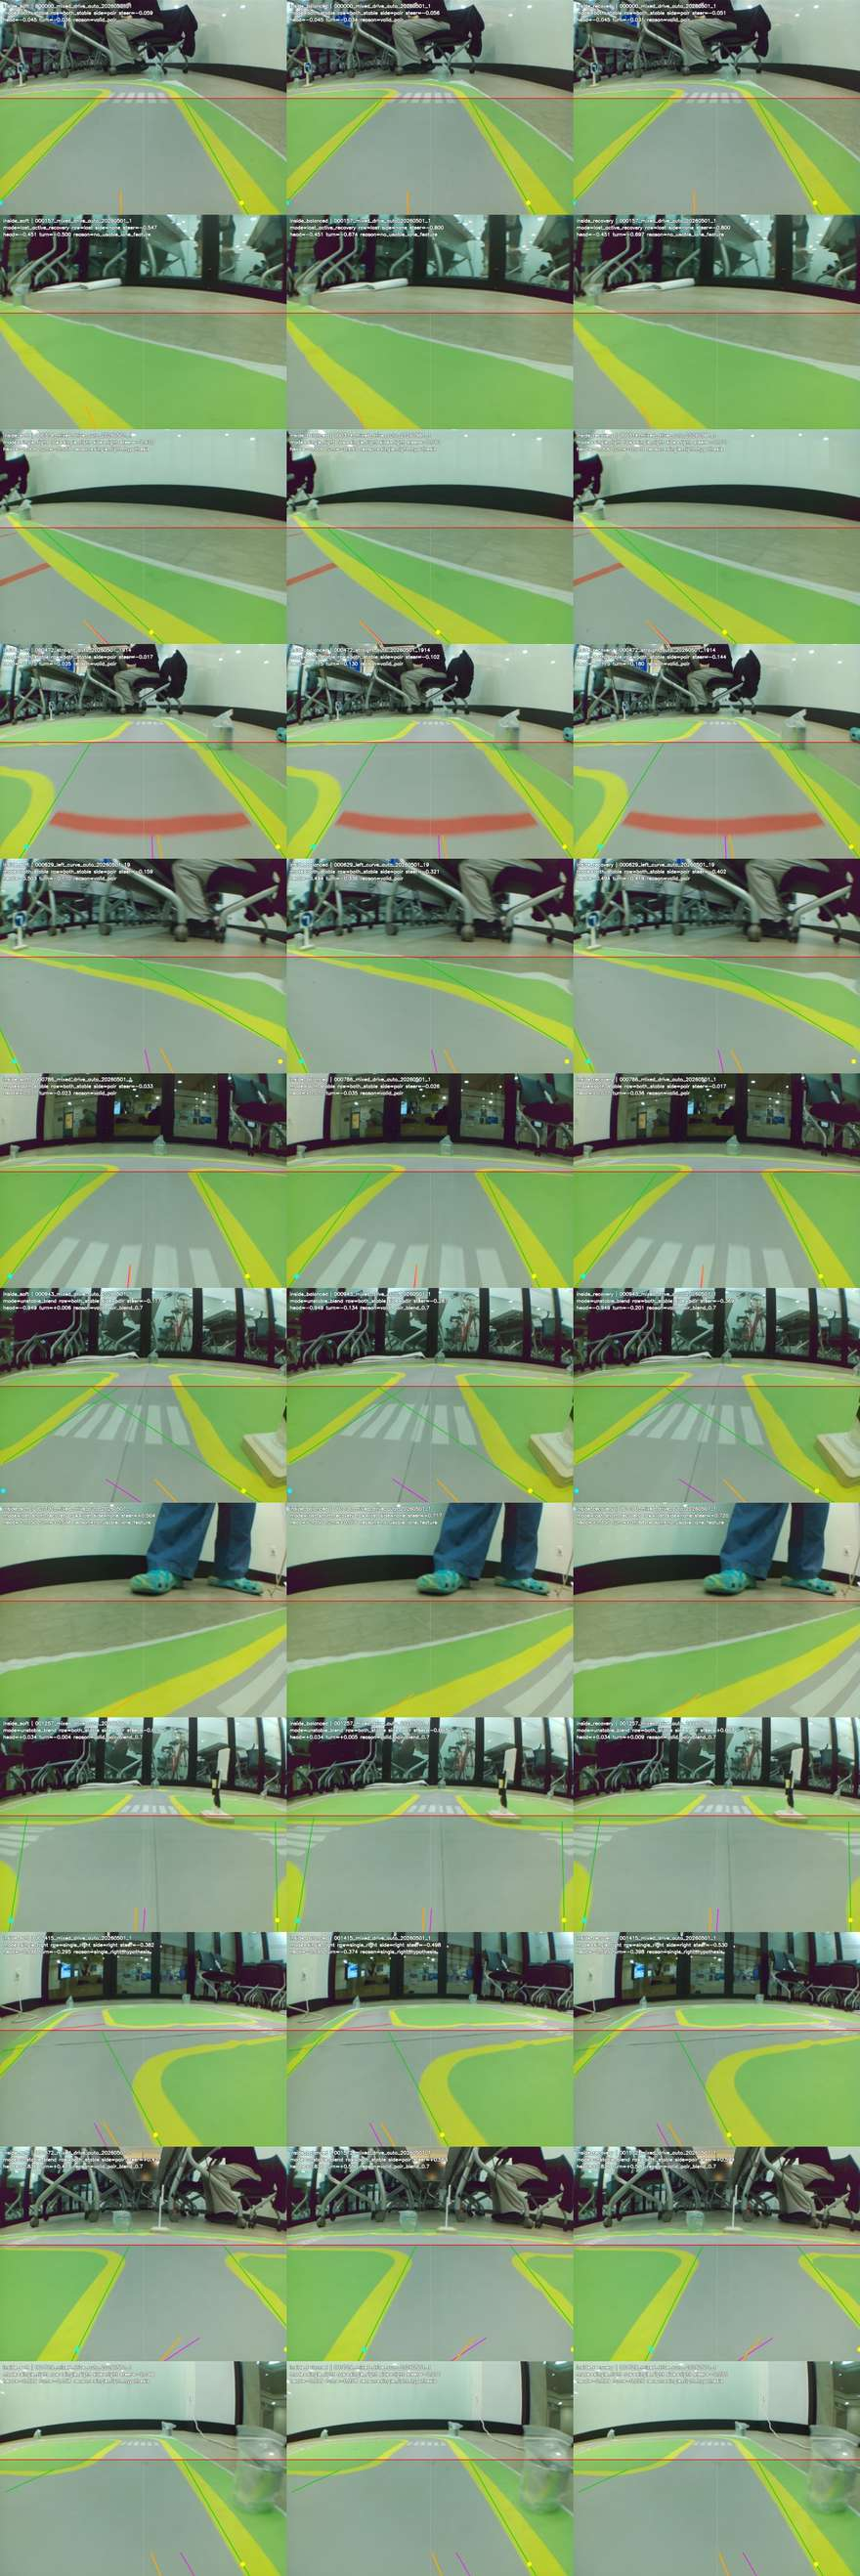

In [15]:
def draw_polyline(out, pts, color, thickness=3):
    pts = np.asarray(pts, dtype=np.float32)
    if len(pts) < 2:
        return
    pts_i = np.round(pts).astype(np.int32)
    for a, b in zip(pts_i[:-1], pts_i[1:]):
        cv2.line(out, tuple(a), tuple(b), color, thickness, cv2.LINE_AA)


def resize_to_width(img, width):
    h, w = img.shape[:2]
    scale = width / w
    return cv2.resize(img, (width, int(round(h * scale))), interpolation=cv2.INTER_AREA)


def make_sheet(images, out_path, thumb_w=430, cols=3):
    thumbs = [resize_to_width(img, thumb_w) for img in images]
    max_h = max(t.shape[0] for t in thumbs)
    rows = []
    for i in range(0, len(thumbs), cols):
        chunk = thumbs[i:i+cols]
        while len(chunk) < cols:
            chunk.append(np.zeros((max_h, thumb_w, 3), dtype=np.uint8))
        padded = []
        for t in chunk:
            if t.shape[0] < max_h:
                pad = np.zeros((max_h - t.shape[0], t.shape[1], 3), dtype=t.dtype)
                t = np.vstack([t, pad])
            padded.append(t)
        rows.append(np.hstack(padded))
    sheet = np.vstack(rows)
    imwrite_bgr(out_path, sheet)
    return out_path


def trajectory_points(center_x, heading, pp):
    y_top = y_at_ratio(pp["top_ratio"])
    y_primary = y_at_ratio(pp["primary_ratio"])
    y_bottom = y_at_ratio(pp["bottom_ratio"])
    if not np.isfinite(center_x):
        return np.empty((0, 2), dtype=np.float32)
    heading = float(heading) if np.isfinite(heading) else 0.0
    x_primary = float(center_x)
    x_top = x_primary + heading * (y_primary - y_top)
    x_bottom = x_primary - heading * (y_bottom - y_primary)
    return np.asarray([[x_top, y_top], [x_primary, y_primary], [x_bottom, y_bottom]], dtype=np.float32)


def draw_drive_panel(bgr, lanes, row, policy_name):
    out = bgr.copy()
    shade = out.copy()
    cv2.rectangle(shade, (0, CUT_HEIGHT), (RAW_W - 1, RAW_H - 1), (0, 70, 0), -1)
    out = cv2.addWeighted(out, 0.84, shade, 0.16, 0)
    cv2.line(out, (0, CUT_HEIGHT), (RAW_W - 1, CUT_HEIGHT), (0, 0, 255), 2)
    cv2.line(out, (int(IMAGE_CENTER_X), CUT_HEIGHT), (int(IMAGE_CENTER_X), RAW_H - 1), (185, 185, 185), 1)

    for lane in lanes:
        draw_polyline(out, lane["points"], (0, 210, 0), thickness=2)

    pp = DRIVE_POLICIES[policy_name]
    y_primary = int(round(y_at_ratio(pp["primary_ratio"])))
    if np.isfinite(row.get("left_x", np.nan)):
        cv2.circle(out, (int(round(row["left_x"])), y_primary), 10, (255, 255, 0), -1)
    if np.isfinite(row.get("right_x", np.nan)):
        cv2.circle(out, (int(round(row["right_x"])), y_primary), 10, (0, 255, 255), -1)

    measured_path = trajectory_points(row.get("measured_center_x", np.nan), row.get("measured_heading", 0.0), pp)
    smoothed_path = trajectory_points(row.get("smoothed_center_x", np.nan), row.get("smoothed_heading", 0.0), pp)
    draw_polyline(out, measured_path, (255, 0, 255), thickness=2)
    draw_polyline(out, smoothed_path, (0, 165, 255), thickness=4)

    lines = [
        f"{policy_name} | {row['id'][:34]}",
        f"mode={row['effective_mode']} raw={row['raw_mode']} side={row.get('selected_side','?')} steer={row['steer_norm']:+.3f}",
        f"head={row['smoothed_heading']:+.3f} turn={row['turn_bias']:+.3f} reason={row['reason']}",
    ]
    y = 34
    for text in lines:
        cv2.putText(out, text, (14, y), cv2.FONT_HERSHEY_SIMPLEX, 0.70, (0, 0, 0), 4, cv2.LINE_AA)
        cv2.putText(out, text, (14, y), cv2.FONT_HERSHEY_SIMPLEX, 0.70, (255, 255, 255), 2, cv2.LINE_AA)
        y += 31
    return out


overlay_records = even_sample(field3_records, 12)
panels = []
for rec in overlay_records:
    bgr = imread_bgr(rec["image_path"])
    key = record_key(rec)
    for policy_name in DRIVE_POLICIES:
        row = policy_frame_df[(policy_frame_df["policy"] == policy_name) & (policy_frame_df["key"] == key)].iloc[0].to_dict()
        panels.append(draw_drive_panel(bgr, decoded_by_key[key], row, policy_name))

if WRITE_OVERLAY:
    overlay_path = OVERLAY_DIR / "inside_memory_policy_compare.jpg"
    make_sheet(panels, overlay_path, thumb_w=430, cols=len(DRIVE_POLICIES))
    print("saved overlay:", overlay_path)
    display(Image(filename=str(overlay_path)))
else:
    overlay_path = None


In [16]:
def write_policy_video(records, out_path, fps=12):
    if not records:
        return None
    first = imread_bgr(records[0]["image_path"])
    sample_panels = []
    key = record_key(records[0])
    for policy_name in DRIVE_POLICIES:
        row = policy_frame_df[(policy_frame_df["policy"] == policy_name) & (policy_frame_df["key"] == key)].iloc[0].to_dict()
        sample_panels.append(resize_to_width(draw_drive_panel(first, decoded_by_key[key], row, policy_name), 420))
    first_frame = np.hstack(sample_panels)
    h, w = first_frame.shape[:2]
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    writer = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
    assert writer.isOpened(), f"failed to open writer: {out_path}"
    lookup = {
        (row["policy"], row["key"]): row
        for row in policy_frame_df.to_dict("records")
    }
    for rec in tqdm(records, desc=f"write {out_path.name}"):
        bgr = imread_bgr(rec["image_path"])
        key = record_key(rec)
        panels = []
        for policy_name in DRIVE_POLICIES:
            row = lookup[(policy_name, key)]
            panel = draw_drive_panel(bgr, decoded_by_key[key], row, policy_name)
            panels.append(resize_to_width(panel, 420))
        frame = np.hstack(panels)
        if frame.shape[:2] != (h, w):
            frame = cv2.resize(frame, (w, h), interpolation=cv2.INTER_AREA)
        writer.write(frame)
    writer.release()
    return out_path


if WRITE_VIDEO:
    video_path = write_policy_video(field3_records, VIDEO_DIR / "inside_memory_policy_compare.mp4", fps=VIDEO_FPS)
    print("saved video:", video_path)
else:
    video_path = None
    print("WRITE_VIDEO=False")


write inside_memory_policy_compare.mp4:   0%|          | 0/1730 [00:00<?, ?it/s]

saved video: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08_driving_postprocess_contract_v1\videos\inside_memory_policy_compare.mp4


## Contract 후보 저장

이 contract는 09 ONNX로 넘어가기 전의 후보이다.

이번 contract에서 명시하는 약속:

- `steer_norm > 0`: 화면 오른쪽으로 조향해야 한다는 의미
- `steer_norm < 0`: 화면 왼쪽으로 조향해야 한다는 의미
- 한쪽 lane은 left/right 두 가설을 모두 비교한 뒤 선택한다
- lane lost 때 차량은 정지하지 않는다. 조향은 최근 회전 기억을 따라 recovery한다.
- `max_steer_norm`은 notebook 내부 cap이고, Pi motor 코드에서는 다시 안전 cap을 둘 수 있다.


In [17]:
def to_jsonable(value):
    if hasattr(value, "item"):
        value = value.item()
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, dict):
        return {str(k): to_jsonable(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_jsonable(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return None
    return value


candidate_policy = str(policy_summary_df.iloc[0]["policy"])
candidate_metric = to_jsonable(policy_summary_df.iloc[0].to_dict())
candidate_params = to_jsonable(DRIVE_POLICIES[candidate_policy])

contract = {
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "notebook": "08_driving_postprocess_contract_v1.ipynb",
    "status": "candidate_after_inside_memory_sweep_pending_visual_review",
    "input_decode_contract": str(DECODE_CONTRACT_PATH),
    "decoder_contract": decoder_cfg,
    "driving_contract": {
        "name": candidate_policy,
        "source": "08 inside-memory steering implementation",
        "design": "minimal lane usability filter + single-lane dual hypothesis + tangent heading + no-stop recovery",
        "selection_rule": "lowest sequence proxy cost, followed by visual inspection of overlay/video",
        "steer_sign_convention": "positive means steer toward image right; negative means steer toward image left",
        "single_lane_policy": "For every single lane, test both left-boundary and right-boundary hypotheses; choose the one with lower temporal-continuity cost.",
        "lane_quality_policy": "No complex lane quality score is used. Lanes only pass simple usability checks: min_points, min_y_span, and local x availability.",
        "params": candidate_params,
        "output": {
            "steer_norm": "normalized steering command in [-max_steer_norm, max_steer_norm] before motor-specific scaling",
            "smoothed_center_x": "display/position component of the smoothed local target trajectory",
            "smoothed_heading": "local target trajectory heading signal; negative means leftward forward trend, positive means rightward forward trend",
            "effective_mode": "both_stable / single_left / single_right / unstable_blend / lost_short_recovery / lost_active_recovery",
        },
        "lost_policy": "The controller does not stop on lost frames. It decays heading and keeps steering from recent turn memory; if no memory exists, it drives straight.",
        "pi_runtime_note": "Before sending to motors, apply a hardware-specific safety cap and verify sign convention on the real car.",
    },
    "field3_sequence_metric": candidate_metric,
    "all_policy_summary_csv": str(POLICY_SUMMARY_CSV),
    "frame_rows_csv": str(POLICY_FRAME_CSV),
    "artifacts": {
        "raw_cache": str(RAW_CACHE_PATH),
        "decoded_lanes_jsonl": str(DECODED_JSONL_PATH),
        "overlay": str(OVERLAY_DIR / "inside_memory_policy_compare.jpg"),
        "video": str(VIDEO_DIR / "inside_memory_policy_compare.mp4"),
        "contract_candidate_json": str(REVIEW_ROOT / "inside_memory_driving_postprocess_contract_candidate.json"),
    },
    "interfaces_to_verify_next": [
        "09 ONNX export: PyTorch raw vs ONNX raw on real images",
        "09 ONNX export: decoded lanes equal after applying 07 decoder contract",
        "09 ONNX export: steering rows equal after applying this 08 driving contract",
        "10 Pi runtime: same 07 decoder + this 08 driving contract",
        "10 Pi runtime: latency for preprocess + inference + decode + inside-memory steering",
    ],
}

CONTRACT_PATH = REVIEW_ROOT / "inside_memory_driving_postprocess_contract_candidate.json"
write_text(CONTRACT_PATH, json.dumps(to_jsonable(contract), ensure_ascii=False, indent=2))
print("saved contract candidate:", CONTRACT_PATH)
print(json.dumps({
    "selected_policy": candidate_policy,
    "selection_cost": candidate_metric["selection_cost"],
    "steer_jitter_norm": candidate_metric["steer_jitter_norm"],
    "pct_lost_active_recovery": candidate_metric["pct_lost_active_recovery"],
    "max_lost_streak": candidate_metric["max_lost_streak"],
}, ensure_ascii=False, indent=2))


saved contract candidate: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08_driving_postprocess_contract_v1\inside_memory_driving_postprocess_contract_candidate.json
{
  "selected_policy": "inside_soft",
  "selection_cost": 13.637740532372899,
  "steer_jitter_norm": 0.04108095364057952,
  "pct_lost_active_recovery": 0.04682080924855491,
  "max_lost_streak": 17
}


## Background Field1/2 replay

Field1/2 background는 학습용 field3과 카메라 각도가 다르다.  
정답 label이 없으므로 F1은 계산하지 않는다.

여기서 보는 것은 다음이다.

- 카메라 각도가 달라도 lane 후보가 유지되는가
- single-lane side가 자주 뒤집히는가
- `steer_norm`이 한쪽으로 오래 포화되는가
- lost recovery가 정지 없이 자연스럽게 이어지는가


In [18]:
BACKGROUND_ROOTS = {
    "background_field1": SHARED_LANE_ROOT / "holdout" / "background_field1",
    "background_field2": SHARED_LANE_ROOT / "holdout" / "background_field2",
}


def collect_background_records(limit_per_set=None):
    records = []
    for set_name, root in BACKGROUND_ROOTS.items():
        paths = sorted([p for p in root.glob("*.jpg") if p.is_file()])
        if limit_per_set is not None:
            paths = paths[:limit_per_set]
        for idx, path in enumerate(paths):
            records.append({
                "set": set_name,
                "id": path.stem,
                "rel": f"{set_name}\\{path.name}",
                "image_path": path,
                "seq_idx": idx,
            })
    return records


background_records = collect_background_records(limit_per_set=None)
print("background records:", len(background_records))
display(pd.Series([r["set"] for r in background_records]).value_counts().rename("count").to_frame())


background records: 734


,count
background_field1,415
background_field2,319


In [19]:
BG_RAW_CACHE_PATH = REVIEW_ROOT / "inside_memory_raw_outputs_background_field12.pt"
BG_RAW_MANIFEST_PATH = REVIEW_ROOT / "inside_memory_raw_outputs_background_field12_manifest.csv"
BG_DECODED_JSONL_PATH = REVIEW_ROOT / "inside_memory_decoded_lanes_background_field12.jsonl"


def manifest_matches_for(path, records):
    if not Path(path).exists():
        return False
    old = pd.read_csv(path)
    new = manifest_from_records(records)
    cols = ["key", "image_path", "size", "mtime_ns"]
    if len(old) != len(new):
        return False
    return old[cols].astype(str).reset_index(drop=True).equals(new[cols].astype(str).reset_index(drop=True))


def build_or_load_raw_cache_for_records(records, raw_cache_path, manifest_path, label):
    raw_cache_path = Path(raw_cache_path)
    manifest_path = Path(manifest_path)
    if raw_cache_path.exists() and manifest_matches_for(manifest_path, records):
        cache = torch.load(long_path(raw_cache_path), map_location="cpu")
        if set(cache.keys()) == {record_key(r) for r in records}:
            print(f"loaded {label} raw cache:", raw_cache_path)
            return cache
        print(f"{label} raw cache key mismatch; rebuilding")

    raw_cache = {}
    start = time.time()
    for rec in tqdm(records, desc=f"forward {label} raw outputs"):
        bgr = imread_bgr(rec["image_path"])
        tensor = preprocess_bgr_for_model(bgr, cfg).to(device)
        with torch.no_grad():
            raw = model({"img": tensor}).detach().cpu()[0]
        raw_cache[record_key(rec)] = raw
    torch.save(raw_cache, long_path(raw_cache_path))
    manifest_from_records(records).to_csv(manifest_path, index=False, encoding="utf-8-sig")
    print(f"saved {label} raw cache:", raw_cache_path)
    print("elapsed_min:", round((time.time() - start) / 60.0, 2))
    return raw_cache


def build_or_load_decoded_lanes_for_records(records, raw_cache, decoded_jsonl_path, label):
    decoded_jsonl_path = Path(decoded_jsonl_path)
    expected_keys = [record_key(r) for r in records]
    if decoded_jsonl_path.exists():
        rows = [json.loads(line) for line in read_text(decoded_jsonl_path).splitlines() if line.strip()]
        if [row["key"] for row in rows] == expected_keys:
            decoded = {row["key"]: row["lanes"] for row in rows}
            print(f"loaded {label} decoded lanes:", decoded_jsonl_path)
            return decoded
        print(f"{label} decoded cache manifest mismatch; rebuilding")

    decoded = {}
    out_lines = []
    for rec in tqdm(records, desc=f"decode {label} lanes"):
        key = record_key(rec)
        lane_objs = decode_one(raw_cache[key])
        lanes = [lane_obj_to_json(l) for l in lane_objs]
        decoded[key] = lanes
        out_lines.append(json.dumps({
            "key": key,
            "set": rec["set"],
            "id": rec["id"],
            "rel": rec["rel"],
            "lanes": lanes,
        }, ensure_ascii=False))
    write_text(decoded_jsonl_path, "\n".join(out_lines) + "\n")
    print(f"saved {label} decoded lanes:", decoded_jsonl_path)
    return decoded


if background_records:
    background_raw_cache = build_or_load_raw_cache_for_records(
        background_records,
        BG_RAW_CACHE_PATH,
        BG_RAW_MANIFEST_PATH,
        label="background",
    )
    background_decoded_by_key = build_or_load_decoded_lanes_for_records(
        background_records,
        background_raw_cache,
        BG_DECODED_JSONL_PATH,
        label="background",
    )
else:
    background_raw_cache = {}
    background_decoded_by_key = {}


forward background raw outputs:   0%|          | 0/734 [00:00<?, ?it/s]

saved background raw cache: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08_driving_postprocess_contract_v1\inside_memory_raw_outputs_background_field12.pt
elapsed_min: 1.26


decode background lanes:   0%|          | 0/734 [00:00<?, ?it/s]

saved background decoded lanes: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08_driving_postprocess_contract_v1\inside_memory_decoded_lanes_background_field12.jsonl


In [20]:
def run_drive_policies_on_records(records, decoded_local, label):
    rows = []
    for policy_name, pp in DRIVE_POLICIES.items():
        # Keep memory separate per sequence/set, because field1 and field2 are different drives.
        memories = {set_name: DriveMemory() for set_name in sorted({r["set"] for r in records})}
        for frame_idx, rec in enumerate(tqdm(records, desc=f"{label} policy {policy_name}")):
            key = record_key(rec)
            result = apply_drive_policy(decoded_local[key], pp, memories[rec["set"]])
            rows.append({
                "policy": policy_name,
                "global_frame_idx": frame_idx,
                "set": rec["set"],
                "id": rec["id"],
                "key": key,
                "rel": rec["rel"],
                "decoded_lane_count": len(decoded_local[key]),
                **result,
            })
    return pd.DataFrame(rows)


background_policy_frame_df = run_drive_policies_on_records(background_records, background_decoded_by_key, "background")
BG_POLICY_FRAME_CSV = TABLE_DIR / "inside_memory_background_policy_frame_rows.csv"
background_policy_frame_df.to_csv(BG_POLICY_FRAME_CSV, index=False, encoding="utf-8-sig")
print("saved:", BG_POLICY_FRAME_CSV)
display(background_policy_frame_df.head())


bg_summary_rows = []
for (set_name, policy_name), g in background_policy_frame_df.groupby(["set", "policy"]):
    row = {"set": set_name, "policy": policy_name}
    row.update(summarize_policy(g))
    bg_summary_rows.append(row)

background_policy_summary_df = pd.DataFrame(bg_summary_rows).sort_values(["set", "selection_cost"]).reset_index(drop=True)
BG_POLICY_SUMMARY_CSV = TABLE_DIR / "inside_memory_background_policy_summary.csv"
background_policy_summary_df.to_csv(BG_POLICY_SUMMARY_CSV, index=False, encoding="utf-8-sig")
display(background_policy_summary_df)
print("saved:", BG_POLICY_SUMMARY_CSV)


background policy inside_soft:   0%|          | 0/734 [00:00<?, ?it/s]

~\AppData\Local\Temp\ipykernel_19128\1422940105.py:37: RuntimeWarning: Mean of empty slice
  x_bottom = np.nanmean([left["x_bottom"], right["x_bottom"]])


background policy inside_balanced:   0%|          | 0/734 [00:00<?, ?it/s]

background policy inside_recovery:   0%|          | 0/734 [00:00<?, ?it/s]

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08_driving_postprocess_contract_v1\tables\inside_memory_background_policy_frame_rows.csv


,policy,global_frame_idx,set,id,key,rel,decoded_lane_count,raw_mode,effective_mode,reason,...,left_x,right_x,pair_gap,selected_side,source_lane_index,hypothesis_cost,feature_count,candidate_count,lost_frames,unstable_frames
0,inside_soft,0,background_field1,20260430_175024_signs_background_moving_mixed_...,background_field1::20260430_175024_signs_backg...,background_field1\20260430_175024_signs_backgr...,2,both_stable,both_stable,valid_pair,...,331.293598,1281.086729,949.793131,pair,-1,79.095082,2,1,0,0
1,inside_soft,1,background_field1,20260430_175025_signs_background_moving_mixed_...,background_field1::20260430_175025_signs_backg...,background_field1\20260430_175025_signs_backgr...,2,both_stable,both_stable,valid_pair,...,331.285583,1281.060238,949.774655,pair,-1,-60.906932,2,1,0,0
2,inside_soft,2,background_field1,20260430_175025_signs_background_moving_mixed_...,background_field1::20260430_175025_signs_backg...,background_field1\20260430_175025_signs_backgr...,2,both_stable,both_stable,valid_pair,...,331.238623,1281.151353,949.912729,pair,-1,-71.658787,2,1,0,0
3,inside_soft,3,background_field1,20260430_175025_signs_background_moving_mixed_...,background_field1::20260430_175025_signs_backg...,background_field1\20260430_175025_signs_backgr...,2,both_stable,both_stable,valid_pair,...,331.186303,1281.264227,950.077924,pair,-1,-76.451202,2,1,0,0
4,inside_soft,4,background_field1,20260430_175025_signs_background_moving_mixed_...,background_field1::20260430_175025_signs_backg...,background_field1\20260430_175025_signs_backgr...,2,both_stable,both_stable,valid_pair,...,331.260281,1281.071653,949.811372,pair,-1,-78.748148,2,1,0,0


,set,policy,frames,pct_both_stable,pct_single_left,pct_single_right,pct_raw_lost,pct_unstable_blend,pct_lost_short_recovery,pct_lost_active_recovery,...,mean_candidate_count,smoothed_center_jitter_px,heading_jitter,steer_jitter_norm,mean_abs_steer_norm,pct_large_center_jump_80px,pct_large_steer_jump_0p18,max_lost_streak,max_unstable_streak,selection_cost
0,background_field1,inside_soft,415,0.674699,0.122892,0.077108,0.125301,0.166265,0.108434,0.016867,...,1.113253,39.973448,0.136279,0.055921,0.211343,0.144928,0.026570,11,3,18.077818
1,background_field1,inside_balanced,415,0.674699,0.122892,0.077108,0.125301,0.187952,0.108434,0.016867,...,1.113253,38.577780,0.134053,0.068083,0.271746,0.137681,0.060386,11,4,23.186632
2,background_field1,inside_recovery,415,0.674699,0.122892,0.077108,0.125301,0.187952,0.108434,0.016867,...,1.113253,38.621749,0.134053,0.073135,0.297636,0.137681,0.089372,11,4,26.594826
3,background_field2,inside_soft,319,0.652038,0.028213,0.097179,0.222571,0.059561,0.112853,0.109718,...,0.909091,17.923574,0.072259,0.036132,0.274852,0.037736,0.003145,30,2,12.992767
4,background_field2,inside_balanced,319,0.652038,0.031348,0.094044,0.222571,0.075235,0.112853,0.109718,...,0.909091,17.345814,0.070072,0.043671,0.330775,0.028302,0.018868,30,2,15.731374
5,background_field2,inside_recovery,319,0.652038,0.031348,0.094044,0.222571,0.075235,0.112853,0.109718,...,0.909091,17.410252,0.070072,0.044722,0.340434,0.028302,0.025157,30,2,16.471882


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08_driving_postprocess_contract_v1\tables\inside_memory_background_policy_summary.csv


saved background overlay: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08_driving_postprocess_contract_v1\overlays\inside_memory_background_field12_policy_compare.jpg


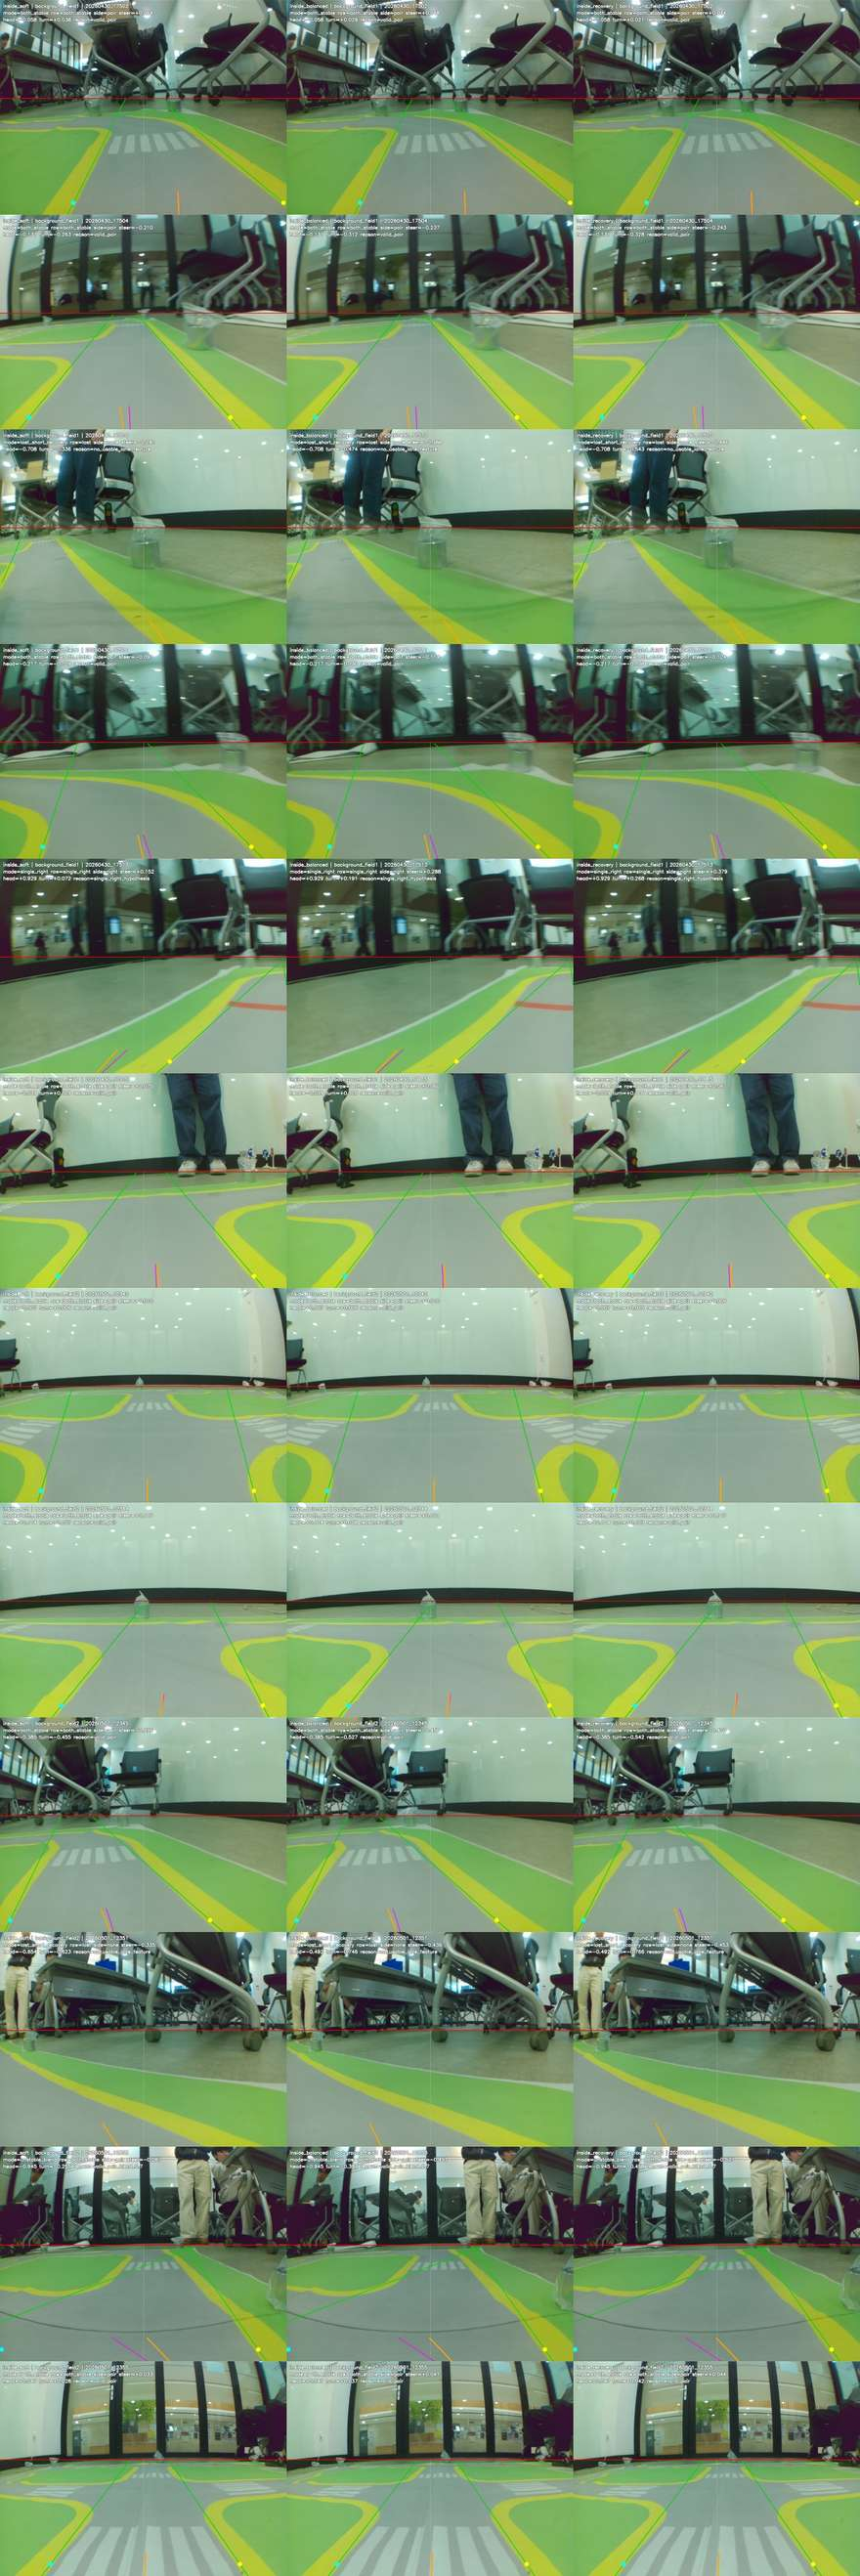

write inside_memory_background_background_field1_policy_compare.mp4:   0%|          | 0/415 [00:00<?, ?it/s]

write inside_memory_background_background_field2_policy_compare.mp4:   0%|          | 0/319 [00:00<?, ?it/s]

saved background videos: [WindowsPath('~/02_Projects/University/26-1_EmbeddedArtificialSystemOptimization/10_experiments/12_clrkdnet_supervised_rebuild/review_outputs/08_driving_postprocess_contract_v1/videos/inside_memory_background_background_field1_policy_compare.mp4'), WindowsPath('~/02_Projects/University/26-1_EmbeddedArtificialSystemOptimization/10_experiments/12_clrkdnet_supervised_rebuild/review_outputs/08_driving_postprocess_contract_v1/videos/inside_memory_background_background_field2_policy_compare.mp4')]


In [21]:
def make_background_overlay(records, decoded_local, frame_df, out_path, frames_per_set=6):
    panels = []
    selected = []
    for set_name in sorted({r["set"] for r in records}):
        set_records = [r for r in records if r["set"] == set_name]
        selected.extend(even_sample(set_records, frames_per_set))

    for rec in selected:
        bgr = imread_bgr(rec["image_path"])
        key = record_key(rec)
        for policy_name in DRIVE_POLICIES:
            row = frame_df[(frame_df["policy"] == policy_name) & (frame_df["key"] == key)].iloc[0].to_dict()
            row["id"] = f"{rec['set']} | {row['id']}"
            panels.append(draw_drive_panel(bgr, decoded_local[key], row, policy_name))

    make_sheet(panels, out_path, thumb_w=430, cols=len(DRIVE_POLICIES))
    return out_path


def write_background_video(records, decoded_local, frame_df, out_dir, fps=12):
    out_paths = []
    lookup = {(row["policy"], row["key"]): row for row in frame_df.to_dict("records")}
    for set_name in sorted({r["set"] for r in records}):
        set_records = [r for r in records if r["set"] == set_name]
        if not set_records:
            continue
        first = imread_bgr(set_records[0]["image_path"])
        sample_panels = []
        key = record_key(set_records[0])
        for policy_name in DRIVE_POLICIES:
            row = dict(lookup[(policy_name, key)])
            row["id"] = f"{set_name} | {row['id']}"
            sample_panels.append(resize_to_width(draw_drive_panel(first, decoded_local[key], row, policy_name), 420))
        first_frame = np.hstack(sample_panels)
        h, w = first_frame.shape[:2]
        out_path = Path(out_dir) / f"inside_memory_background_{set_name}_policy_compare.mp4"
        writer = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
        assert writer.isOpened(), f"failed to open writer: {out_path}"
        for rec in tqdm(set_records, desc=f"write {out_path.name}"):
            bgr = imread_bgr(rec["image_path"])
            key = record_key(rec)
            panels = []
            for policy_name in DRIVE_POLICIES:
                row = dict(lookup[(policy_name, key)])
                row["id"] = f"{set_name} | {row['id']}"
                panel = draw_drive_panel(bgr, decoded_local[key], row, policy_name)
                panels.append(resize_to_width(panel, 420))
            frame = np.hstack(panels)
            if frame.shape[:2] != (h, w):
                frame = cv2.resize(frame, (w, h), interpolation=cv2.INTER_AREA)
            writer.write(frame)
        writer.release()
        out_paths.append(out_path)
    return out_paths


BG_OVERLAY_PATH = OVERLAY_DIR / "inside_memory_background_field12_policy_compare.jpg"
if WRITE_OVERLAY:
    make_background_overlay(background_records, background_decoded_by_key, background_policy_frame_df, BG_OVERLAY_PATH)
    print("saved background overlay:", BG_OVERLAY_PATH)
    display(Image(filename=str(BG_OVERLAY_PATH)))

if WRITE_VIDEO:
    bg_video_paths = write_background_video(background_records, background_decoded_by_key, background_policy_frame_df, VIDEO_DIR, fps=VIDEO_FPS)
    print("saved background videos:", bg_video_paths)
else:
    bg_video_paths = []


### Background replay 해석

Background replay는 label이 없기 때문에 정답률을 보지 않는다.

확인할 것:

- `raw_lost`가 너무 많으면 모델/decoder가 해당 카메라 각도에서 lane을 못 보는 것이다.
- `selected_side`가 자주 뒤집히면 single-lane 가설 선택이 불안정한 것이다.
- `steer_norm`이 오래 포화되면 Pi에서 motor cap을 더 낮춰야 한다.
- 영상에서 주황 ray가 차선 바깥으로 도망가면 `safe_offset_px`나 `k_heading`을 다시 봐야 한다.


## 다음 단계

Run All 이후에는 다음 순서로 본다.

1. `inside_memory_policy_summary.csv`에서 세 정책의 안정성 지표를 비교한다.
2. `inside_memory_policy_compare.jpg`와 `.mp4`에서 field3 좌/우회전/lost 구간의 주황 ray를 본다.
3. `inside_memory_background_policy_summary.csv`와 background video에서 field1/2 카메라 각도 robustness를 본다.
4. 한쪽 lane 오판이 줄었는지 `selected_side`, `reason`, `effective_mode`를 같이 확인한다.
5. 영상 검수까지 통과하면 이 08 contract를 기준으로 09 ONNX export/parity로 넘어간다.

조절 우선순위:

```text
single-lane offset 문제  → safe_offset_px
곡선 반응이 약함         → k_heading 증가
직선 복귀가 늦음         → jump_blend_start/max 증가, heading_alpha 증가
너무 과격하게 돈다       → max_steer_norm 감소, k_heading 감소
lost에서 너무 급히 돈다  → recovery_gain / recovery_ramp 감소
```


## 실주행 튜닝용 steering profile 정리

08 노트북에서 정하는 것은 모델 weight가 아니라, Pi runtime에서 lane 좌표를 조향값으로 바꾸는 후처리 함수다.

고정된 base는 아래와 같다.

- 학습 모델: `MapLane_LocalFit_Field12_v1`의 `best.pth`
- decoder: 07에서 확정한 `official_overlap_python`
- decoder 값: `conf_threshold=0.35`, `nms_thres=70`, `nms_topk=4`
- 입력: decoder가 뽑은 lane 좌표들
- 출력: Pi 모터 코드로 넘길 `steer_norm`

따라서 실험실 맵에서 바꿔볼 대상은 모델이 아니라 08의 steering profile 값들이다. 같은 ONNX 모델과 같은 decoder를 두고, 아래 값만 바꿔가며 주행 로그를 비교하면 된다.

### 지금까지 비교한 두 계열

`tangent_recovery` 계열은 heading을 강하게 믿는 방식이다.

- 장점: 곡선에서 local lane 방향을 잘 따라가고, field3 영상 기준 heading/steer jitter가 작았다.
- 단점: 잘못된 heading이나 이전 회전 방향을 오래 물고 갈 수 있다.
- 대표 후보: `tangent_recovery_strong`
- 핵심 값: `k_heading`이 크고, jump frame에서 새 heading을 매우 조금만 반영한다.

`inside_memory` 계열은 한쪽 lane을 바로 left/right로 고정하지 않고, left-boundary/right-boundary 가설을 둘 다 만든 뒤 시간 기억으로 고르는 방식이다.

- 장점: 한쪽 lane side 오판을 줄이려는 구조이고, 복잡한 lane quality score를 제거했다.
- 단점: 현재 결과에서는 field3의 center/heading jitter가 `tangent_recovery`보다 커졌다.
- 대표 후보: `inside_soft`
- 핵심 값: `safe_offset_px`, `k_pos`, `k_heading`, `heading_alpha`, `jump_blend_*`, `recovery_gain/ramp`

### 실험실에서 볼 것

실주행에서는 아래 항목을 profile별로 기록한다.

- 완주 여부
- 이탈한 위치와 프레임
- 좌/우 곡선 진입 시 조향 반응
- 직선 복귀 후 과거 heading을 오래 물고 가는지
- 한쪽 lane만 보일 때 안쪽으로 안정적으로 붙는지
- lost 구간에서 멈추지 않고 lane이 다시 보이는 방향으로 회복하는지
- `steer_norm`이 너무 자주 cap에 닿는지

### 현재 판단

08의 결론은 아직 최종 steering contract 확정이 아니다. 지금은 Pi에 올릴 수 있는 후보 profile들을 정리한 단계다.

09 노트북부터는 steering 값 자체를 확정하기보다, 먼저 모델 배포 경로를 엄밀하게 확인한다.

1. PyTorch `best.pth`와 ONNX raw output이 같은지 확인한다.
2. 같은 07 decoder를 적용했을 때 lane 좌표가 같은지 확인한다.
3. 08 steering 함수도 같은 입력에 대해 같은 `steer_norm`을 내는지 확인한다.
4. 이후 Pi에서 같은 decoder + steering profile을 쓰고 latency와 실제 주행을 확인한다.

즉 09의 목적은 steering 튜닝을 끝내는 것이 아니라, 이후 실험실에서 profile 값만 바꿔도 되는 배포/검증 기반을 만드는 것이다.
